<a href="https://colab.research.google.com/github/dechl-98/ChavezDavid2534532021/blob/main/ClaveG/Ejercicio3_Clusterizaci%C3%B3n_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#Caso 3 Agrupación de datos ClaveG_agrupacion
#Importando las librerías que se necesitarán para trabajar y presentar los datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [17]:
#Mandamos a llamar la data desde el repositorio e imprimimos los resultados actuales
url = "https://raw.githubusercontent.com/dechl-98/ChavezDavid2534532021/refs/heads/main/ClaveG/clave_G_agrupacion.csv"
df = pd.read_csv(url)
print(df.head())
print(df.shape)
print(df.info())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     G-R0007    33       631            3.98           15.70          6.07   
1     G-R0123    44       995            6.13           75.82          7.87   
2     G-R0009    28       509            1.30           30.45          5.97   
3     G-R0228    46       769            2.94           69.77          5.28   
4     G-R0106    37      1069            5.56           83.50          8.27   

   reclamos  antiguedad_meses  
0         3                 1  
1         2                32  
2         5                 1  
3        12                21  
4         1                 8  
(254, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       254 non-null    object 
 1   edad              254 non-null    int64  
 2   ingresos          254 non-n

contemplamos un total de 254 registros, 8 columnas

In [18]:
#Revisión de valores nulos y duplicados
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

no se reportan valores nulos nii duplicados

In [19]:
#Verificamos valores numericos y revisamos variables atípicas
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for columna in numerical_cols:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(f"Columna: {columna}, Límite Inferior: {limite_inferior:.2f}, Límite Superior: {limite_superior:.2f}, Cantidad de Atípicos: {len(atipicos)}")

Columna: edad, Límite Inferior: 20.11, Límite Superior: 59.70, Cantidad de Atípicos: 9
Columna: ingresos, Límite Inferior: 187.35, Límite Superior: 2006.11, Cantidad de Atípicos: 2
Columna: frecuencia_uso, Límite Inferior: -0.31, Límite Superior: 11.37, Cantidad de Atípicos: 6
Columna: gasto_promedio, Límite Inferior: -13.10, Límite Superior: 184.37, Cantidad de Atípicos: 4
Columna: satisfaccion, Límite Inferior: 2.97, Límite Superior: 11.04, Cantidad de Atípicos: 4
Columna: reclamos, Límite Inferior: -1.93, Límite Superior: 6.81, Cantidad de Atípicos: 9
Columna: antiguedad_meses, Límite Inferior: -8.04, Límite Superior: 46.44, Cantidad de Atípicos: 11


The previous error indicated that `X_scaled_df` contains NaN values, likely due to the `satisfaccion` column having one missing entry as seen in `df.info()`. K-Means cannot handle NaNs. We will impute this missing value using the mean of the `satisfaccion` column before scaling.

In [20]:
# Impute missing values in 'satisfaccion' column with the mean
if 'satisfaccion' in df.columns and df['satisfaccion'].isnull().any():
    df['satisfaccion'] = df['satisfaccion'].fillna(df['satisfaccion'].mean())
    print("Missing values in 'satisfaccion' filled with mean.")

numerical_cols_for_clustering = df.select_dtypes(include=np.number).columns.tolist()
X = df[numerical_cols_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for easier interpretation of centroids later
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols_for_clustering)

print("\nCheck for NaNs after imputation and scaling:")
print(X_scaled_df.isnull().sum())

Missing values in 'satisfaccion' filled with mean.

Check for NaNs after imputation and scaling:
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


In [21]:
modelo_k4 = KMeans(n_clusters=4, random_state=0, n_init=10)
df["clusterk4"] = modelo_k4.fit_predict(X_scaled_df)

# To get centroids in original scale, inverse transform the scaled centroids
centroides_k4 = pd.DataFrame(scaler.inverse_transform(modelo_k4.cluster_centers_), columns=numerical_cols_for_clustering)
print("\nCentroides de los clusters (valores originales):")
print(centroides_k4)
print("\nConteo de registros por cluster:")
print(df["clusterk4"].value_counts())


Centroides de los clusters (valores originales):
        edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0  28.515625   629.578125        2.276563       38.650938      6.060469   
1  51.366667  1731.666667        9.075500      157.002333      8.939891   
2  43.310345   921.155172        4.097586       60.181897      4.365345   
3  37.736111  1124.291667        6.634861       88.429167      8.353056   

   reclamos  antiguedad_meses  
0  3.218750          8.328125  
1  0.616667         38.016667  
2  5.362069         12.672414  
3  0.902778         18.444444  

Conteo de registros por cluster:
clusterk4
3    72
0    64
1    60
2    58
Name: count, dtype: int64


In [23]:
# Initialize KMeans models for 4 and 5 clusters
modelo_k4_adaptado = KMeans(n_clusters=4, random_state=42, n_init=10)
modelo_k5_adaptado = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit and predict for 4 clusters
df['Cluster_4'] = modelo_k4_adaptado.fit_predict(X_scaled_df)

# Fit and predict for 5 clusters
df['Cluster_5'] = modelo_k5_adaptado.fit_predict(X_scaled_df)

# Get centroids in original scale for 4 clusters, using column names from X_scaled_df
centroides_k4_adaptado = pd.DataFrame(scaler.inverse_transform(modelo_k4_adaptado.cluster_centers_), columns=X_scaled_df.columns.tolist())
print("\nCentroides para 4 clusters (valores originales):")
print(centroides_k4_adaptado.round(2))
print("\nConteo de registros por cluster (4 clusters):")
print(df['Cluster_4'].value_counts())

# Get centroids in original scale for 5 clusters, using column names from X_scaled_df
centroides_k5_adaptado = pd.DataFrame(scaler.inverse_transform(modelo_k5_adaptado.cluster_centers_), columns=X_scaled_df.columns.tolist())
print("\nCentroides para 5 clusters (valores originales):")
print(centroides_k5_adaptado.round(2))
print("\nConteo de registros por cluster (5 clusters):")
print(df['Cluster_5'].value_counts())


Centroides para 4 clusters (valores originales):
    edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0  43.31    921.16            4.10           60.18          4.37      5.36   
1  51.37   1731.67            9.08          157.00          8.94      0.62   
2  28.52    629.58            2.28           38.65          6.06      3.22   
3  37.74   1124.29            6.63           88.43          8.35      0.90   

   antiguedad_meses  
0             12.67  
1             38.02  
2              8.33  
3             18.44  

Conteo de registros por cluster (4 clusters):
Cluster_4
3    72
2    64
1    60
0    58
Name: count, dtype: int64

Centroides para 5 clusters (valores originales):
    edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0  37.74   1124.29            6.63           88.43          8.35      0.90   
1  43.44    925.26            4.11           60.65          4.33      5.35   
2  51.37   1731.67            9.08          157.00

Let's visualize the relationship between two of the numerical features in your dataset. We'll use 'edad' (age) and 'ingresos' (income) as replacements for the 'education' and 'prestige' columns from the original prompt, and adapt the plot accordingly.

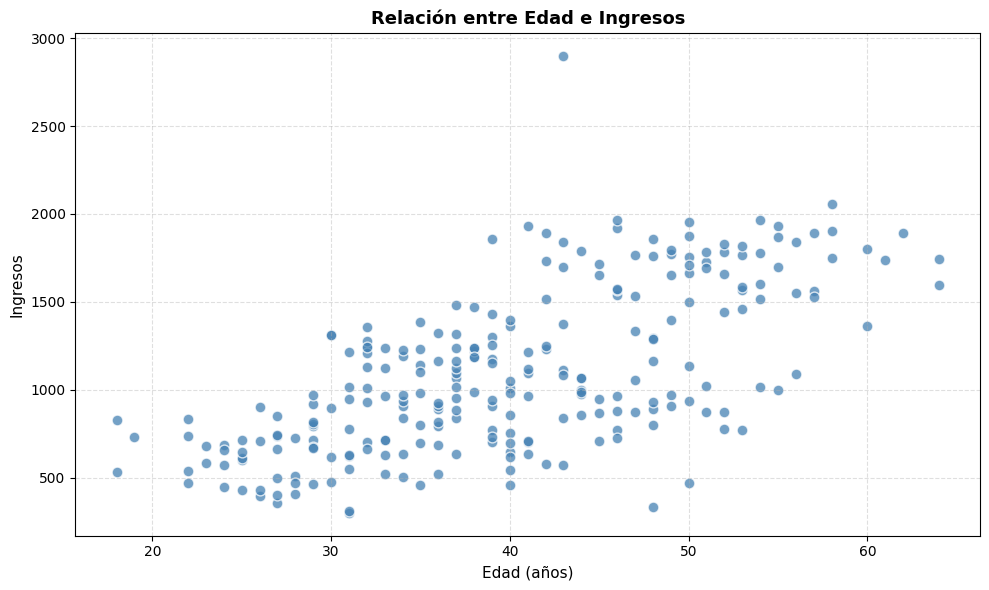

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(df['edad'], df['ingresos'], color='steelblue', alpha=0.75, edgecolors='white', s=60)
plt.xlabel('Edad (años)', fontsize=11)
plt.ylabel('Ingresos', fontsize=11)
plt.title('Relación entre Edad e Ingresos', fontsize=13, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Let's now visualize the average 'gasto_promedio' for each of the 4 clusters we identified earlier. This will help us understand how average spending varies across the different customer segments.

/tmp/ipykernel_3231/4052822632.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_clusters, fontsize=9)


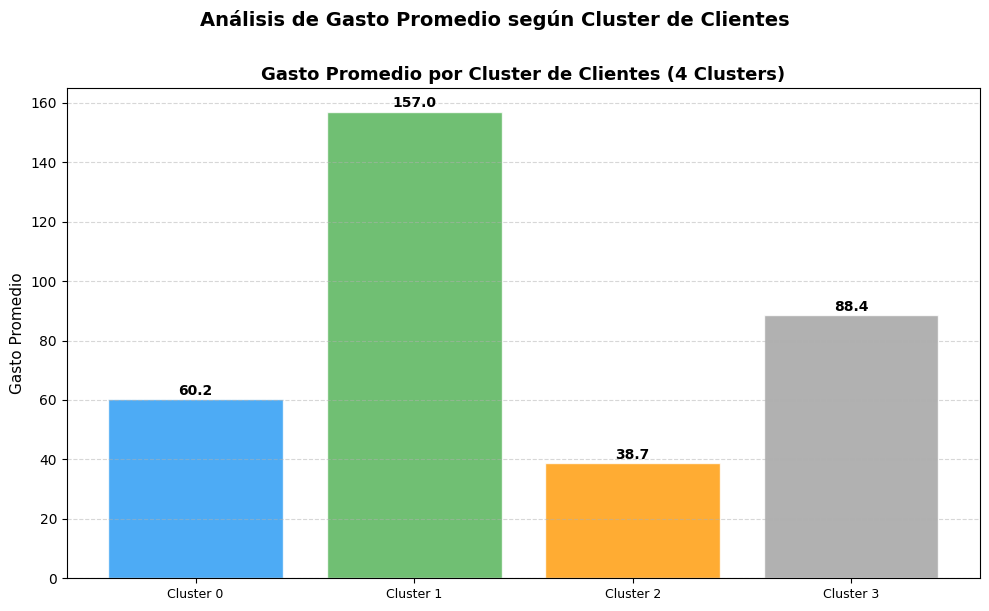

Gasto promedio por cluster de clientes:


,mean,median,std,count
Cluster_4_Label,,,,
Cluster 0,60.18,59.55,19.51,58
Cluster 1,157.00,157.64,17.51,60
Cluster 2,38.65,33.76,32.95,64
Cluster 3,88.43,88.17,18.17,72


In [27]:
# Map cluster numbers to meaningful labels for better visualization
cluster_labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
df['Cluster_4_Label'] = df['Cluster_4'].map(cluster_labels_map)

orden_clusters = [cluster_labels_map[i] for i in sorted(cluster_labels_map.keys())]
colors_box = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E'] # Example colors, can be customized

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate average 'gasto_promedio' for each cluster
promedios_gasto = df.groupby('Cluster_4_Label')['gasto_promedio'].mean().reindex(orden_clusters)
bars = ax.bar(orden_clusters, promedios_gasto.values, color=colors_box, alpha=0.8, edgecolor='white')

# Add value labels on top of the bars
for bar, val in zip(bars, promedios_gasto.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Gasto Promedio', fontsize=11)
ax.set_title('Gasto Promedio por Cluster de Clientes (4 Clusters)', fontsize=13, fontweight='bold')
# Set x-ticks explicitly before setting labels to address UserWarning
ax.set_xticks(range(len(orden_clusters)))
ax.set_xticklabels(orden_clusters, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Análisis de Gasto Promedio según Cluster de Clientes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Gasto promedio por cluster de clientes:")
display(df.groupby('Cluster_4_Label')['gasto_promedio'].agg(['mean', 'median', 'std', 'count']).round(2))